AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

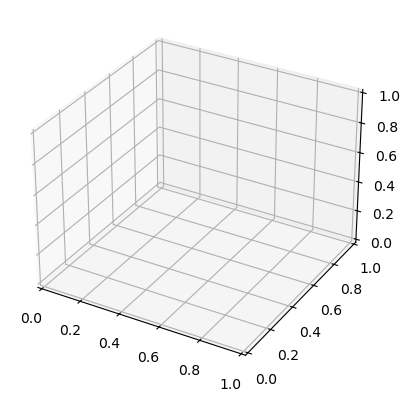

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises

# Create the spherical grid
def create_sphere_grid(n_theta, n_phi):
    theta = np.linspace(0, np.pi, n_theta)  # Polar angle
    phi = np.linspace(0, 2*np.pi, n_phi)    # Azimuthal angle
    theta, phi = np.meshgrid(theta, phi)
    return theta, phi
# Define a function on the sphere using a von Mises distribution
def spherical_function(theta, phi):
    # Parameters for the von Mises distribution
    kappa = 10  # Concentration parameter
    center_theta = np.pi / 4
    
    # Compute the von Mises distribution on the sphere
    return vonmises.pdf(theta, kappa, loc=center_theta) 

# Plot the function on the sphere
def plot_spherical_function(theta, phi, func_values):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Convert spherical to Cartesian coordinates for plotting
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Plot the surface
    ax.plot_surface(x, y, z, facecolors=plt.cm.viridis(func_values), rstride=1, cstride=1, alpha=0.7)
    plt.axis('off')
    plt.show()
    


def spherical_harmonics_representation(theta, phi, func_values, l_max=4):
    """
    Compute the spherical harmonic coefficients of a function defined on the sphere.
    
    Parameters:
        theta (2D array): Polar angles on the sphere.
        phi (2D array): Azimuthal angles on the sphere.
        func_values (2D array): Values of the function on the sphere.
        l_max (int): Maximum degree of spherical harmonics.
    
    Returns:
        coefficients (2D complex array): Spherical harmonic coefficients.
    """
    coefficients = np.zeros((l_max + 1, 2 * l_max + 1), dtype=complex)
    dtheta = theta[1, 0] - theta[0, 0]
    dphi = phi[0, 1] - phi[0, 0]

    # Loop over all degrees and orders
    for l in range(l_max + 1):
        for m in range(-l, l + 1):
            # Compute spherical harmonic Y_lm
            Y_lm = sph_harm(m, l, phi, theta)

            # Compute the integral using discretized summation
            integral = np.sum(func_values * Y_lm.conj() * np.sin(theta)) * dtheta * dphi
            
            # Store the coefficient
            coefficients[l, m + l] = integral

    return coefficients

# Reconstruct the function from spherical harmonics coefficients
def reconstruct_from_coefficients(coefficients, theta, phi, l_max=4):
    reconstructed_values = np.zeros_like(theta, dtype=complex)
    for l in range(l_max + 1):
        for m in range(-l, l + 1):
            Y_lm = sph_harm(m, l, phi, theta)
            reconstructed_values += coefficients[l, m + l] * Y_lm
    return np.real(reconstructed_values)

# Create the grid
n_theta, n_phi = 100, 200
theta, phi = create_sphere_grid(n_theta, n_phi)

# Define the function on the sphere
func_values = spherical_function(theta, phi)



# Create the grid
n_theta, n_phi = 100, 200
theta, phi = create_sphere_grid(n_theta, n_phi)

# Define the function on the sphere
func_values = spherical_function(theta, phi)

# Plot the original function
plot_spherical_function(theta, phi, func_values)

# Spherical harmonics representation
coeffs = spherical_harmonics_representation(theta, phi, func_values)

# Reconstruct the function
reconstructed_func_values = reconstruct_from_coefficients(coeffs, theta, phi)

# Plot the reconstructed function
plot_spherical_function(theta, phi, reconstructed_func_values)

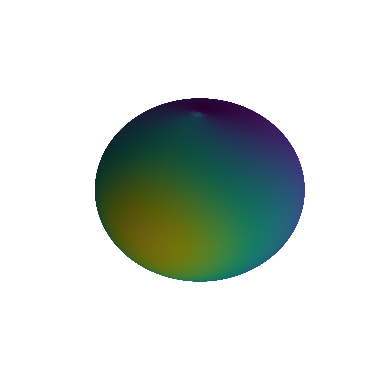

/tmp/ipykernel_6492/998820231.py:90: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_lm = sph_harm(m, l, phi, theta)
/tmp/ipykernel_6492/998820231.py:114: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_lm = sph_harm(m, l, phi, theta)


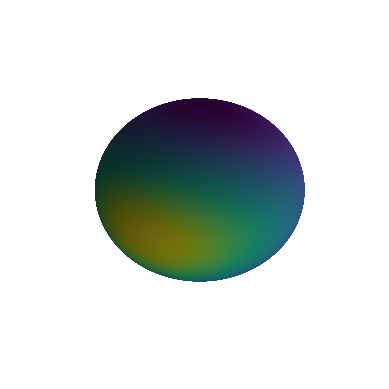

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises

# ------------------------------------------------------
# 1) Create the spherical grid with 'ij' indexing
# ------------------------------------------------------
def create_sphere_grid(n_theta, n_phi):
    """
    Returns:
        theta, phi with shape (n_theta, n_phi).
        theta in [0, pi], phi in [0, 2*pi].
    """
    theta_vals = np.arccos(1 - 2 * np.linspace(0, 1, n_theta))
    phi_vals   = np.linspace(0, 2 * np.pi, n_phi)
    # Use 'ij' so that theta varies along the first axis, phi along the second
    theta, phi = np.meshgrid(theta_vals, phi_vals, indexing='ij')
    return theta, phi

# ------------------------------------------------------
# 2) Define a function on the sphere
#    Here we use a von Mises in the theta direction
# ------------------------------------------------------
def spherical_function(theta, phi):
    """
    A sample function that depends only on theta, using a 1D von Mises PDF.
    """
    kappa = 1  # Concentration parameter
    mu_theta = np.pi/2  # Mean direction for theta
    mu_phi = np.pi*1.5  # Mean direction for phi
    pdf_theta = vonmises.pdf(theta, kappa, loc=mu_theta)
    pdf_phi = vonmises.pdf(phi, kappa, loc=mu_phi)
    return pdf_theta * pdf_phi
# ------------------------------------------------------
# 3) Utility to plot a spherical function
#    Input arrays: theta, phi, func_values with shape (n_theta, n_phi)
# ------------------------------------------------------
def plot_spherical_function(theta, phi, func_values):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Convert spherical to Cartesian for plotting
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Plot the surface (color it by the function value)
    # Ensure func_values is normalized for color mapping
    norm_vals = (func_values - func_values.min()) / (np.ptp(func_values) + 1e-15)
    
    ax.plot_surface(
        x, y, z, 
        facecolors=plt.cm.viridis(norm_vals),
        rstride=1, cstride=1, alpha=0.7
    )
    plt.axis('off')
    plt.show()

# ------------------------------------------------------
# 4) Compute spherical harmonic coefficients
# ------------------------------------------------------
def spherical_harmonics_representation(theta, phi, func_values, l_max=4):
    """
    Compute the spherical harmonic coefficients of a function defined on a spherical grid.
    
    Parameters:
        theta (2D array): shape (n_theta, n_phi), polar angles [0, pi].
        phi   (2D array): shape (n_theta, n_phi), azimuthal angles [0, 2*pi].
        func_values (2D array): same shape, values of the function.
        l_max (int): maximum spherical harmonic degree.
    
    Returns:
        coefficients (2D complex array): shape (l_max+1, 2*l_max+1).
    """
    # Infer the number of sample points
    n_theta, n_phi = theta.shape
    
    # Integration increments
    dtheta = np.pi / (n_theta - 1)
    dphi   = 2*np.pi / (n_phi - 1)

    coefficients = np.zeros((l_max + 1, 2*l_max + 1), dtype=complex)
    
    # Loop over all degrees l and orders m
    for l in range(l_max + 1):
        for m in range(-l, l + 1):
            # Compute the spherical harmonic Y_l^m(phi, theta)
            Y_lm = sph_harm(m, l, phi, theta)
            # Discrete approximation to the integral:
            #   ∫ f(θ,φ) * Y_lm^*(θ,φ) * sin(θ) dθ dφ
            # Summation over all grid points:
            integrand = func_values * Y_lm.conj() * np.sin(theta)
            integral = np.sum(integrand) * dtheta * dphi
            
            # Store the coefficient
            coefficients[l, m + l] = integral
    
    return coefficients

# ------------------------------------------------------
# 5) Reconstruct the function from spherical harmonics coefficients
# ------------------------------------------------------
def reconstruct_from_coefficients(coefficients, theta, phi, l_max=4):
    """
    Reconstruct the function on the same (theta, phi) grid from
    the given spherical harmonic coefficients.
    """
    reconstructed_values = np.zeros_like(theta, dtype=complex)
    # Loop over all degrees l and orders m
    for l in range(l_max + 1):
        for m in range(-l, l + 1):
            Y_lm = sph_harm(m, l, phi, theta)
            reconstructed_values += coefficients[l, m + l] * Y_lm

    return np.real(reconstructed_values)

# ------------------------------------------------------
# MAIN SCRIPT
# ------------------------------------------------------
# Create the grid
n_theta, n_phi = 500, 500
theta, phi = create_sphere_grid(n_theta, n_phi)

# Define the function on the sphere
func_values = spherical_function(theta, phi)

# Plot the original function
plot_spherical_function(theta, phi, func_values)

# Compute spherical harmonics representation
coeffs = spherical_harmonics_representation(theta, phi, func_values, l_max=4)

# Reconstruct the function from the coefficients
reconstructed_func_values = reconstruct_from_coefficients(coeffs, theta, phi, l_max=4)

# Plot the reconstructed function
plot_spherical_function(theta, phi, reconstructed_func_values)


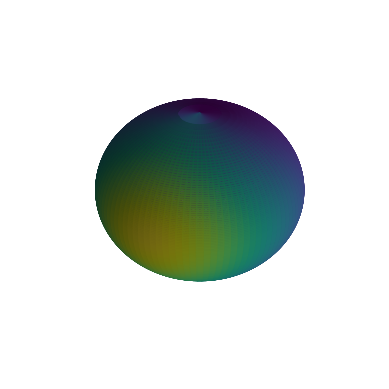

In [45]:
%matplotlib inline

# Plot the function on the sphere
plot_spherical_function(theta, phi, func_values)


In [15]:

# Create the grid
n_theta, n_phi = 100, 200
theta, phi = create_sphere_grid(n_theta, n_phi)

# Define the function on the sphere
func_values = spherical_function(theta, phi)

# Spherical harmonics representation of the function
coeffs = spherical_harmonics_representation(theta, phi, func_values, l_max=12)


/tmp/ipykernel_6492/1246795843.py:60: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_lm = sph_harm(m, l, phi, theta)


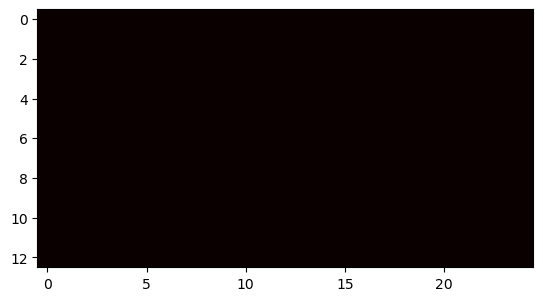

In [16]:
plt.imshow(coeffs.real, cmap='hot', interpolation='nearest')
plt.show()

In [17]:
coeffs

array([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -0.+0.j, -0.+0.j,  0.+0.j, -0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0

/tmp/ipykernel_6492/4086527064.py:55: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_lm = sph_harm(m, l, phi, theta)


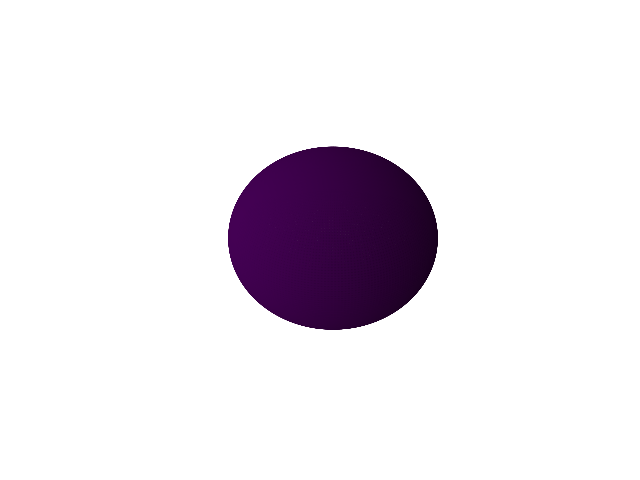

In [5]:

# # Perform a simple convolution in the spherical harmonics domain
# conv_coeffs = spherical_convolution(coeffs)
%matplotlib widget
# Reconstruct the convolved function from the convolved spherical harmonics coefficients
conv_func_values = reconstruct_from_coefficients(coeffs, theta, phi, l_max=8)

# Plot the convolved function on the sphere
plot_spherical_function(theta, phi, conv_func_values)

In [6]:
conv_func_values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(200, 100))